# Actividad 8: Sarsa vs Q-learning en Cliff Walking
## Héctor Arturo Hernández Escalante
### Profesor: Dr. Victor Uc
### Maestría en Ciencias de la Computación
### Segundo Semestre
### Universidad Autónoma de Yucatán
### 21 de Mayo 2026


### 1. Introduction
In this activity, we compare two fundamental Temporal-Difference (TD) control algorithms: **Sarsa** (on-policy) and **Q-learning** (off-policy). We use the **Cliff Walking** environment (Example 6.6 from Sutton & Barto's book) to illustrate their differences in behavior and performance.

The Cliff Walking environment is a gridworld where the agent must move from a start state to a goal state while avoiding a "cliff".
- **Sarsa update**: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma Q(s', a') - Q(s, a)]$
- **Q-learning update**: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$


### 2. Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt


### 3. Environment Definition: Cliff Walking
We define the 4x12 grid world. The bottom row contains the start state (3, 0), the goal state (3, 11), and the "cliff" (3, 1 to 3, 10).

In [12]:
# Configuración del entorno Cliff Walking
WORLD_HEIGHT = 4
WORLD_WIDTH = 12

# Acciones
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
ACTIONS = [UP, DOWN, LEFT, RIGHT]

# Posiciones especiales
START_STATE = [3, 0]
GOAL_STATE = [3, 11]

def step(state, action):
    i, j = state
    if action == UP:
        next_state = [max(i - 1, 0), j]
    elif action == DOWN:
        next_state = [min(i + 1, WORLD_HEIGHT - 1), j]
    elif action == LEFT:
        next_state = [i, max(j - 1, 0)]
    elif action == RIGHT:
        next_state = [i, min(j + 1, WORLD_WIDTH - 1)]
    
    reward = -1
    # Check if the agent fell into the cliff
    if (next_state[0] == 3) and (1 <= next_state[1] <= 10):
        reward = -100
        next_state = START_STATE
    
    return next_state, reward

def choose_action(state, q_value, epsilon):
    if np.random.binomial(1, epsilon) == 1:
        return np.random.choice(ACTIONS)
    else:
        values_ = q_value[state[0], state[1], :]
        return np.random.choice([action_ for action_, value_ in enumerate(values_) if value_ == np.max(values_)])


### 4. Algorithm Implementation
#### 4.1 Sarsa (On-policy TD Control)

In [13]:
def sarsa(q_value, step_size, epsilon=0.1):
    state = START_STATE
    action = choose_action(state, q_value, epsilon)
    rewards = 0
    while state != GOAL_STATE:
        next_state, reward = step(state, action)
        next_action = choose_action(next_state, q_value, epsilon)
        rewards += reward
        target = q_value[next_state[0], next_state[1], next_action]
        q_value[state[0], state[1], action] += step_size * (reward + target - q_value[state[0], state[1], action])
        state = next_state
        action = next_action
    return rewards


#### 4.2 Q-Learning (Off-policy TD Control)

In [14]:
def q_learning(q_value, step_size, epsilon=0.1):
    state = START_STATE
    rewards = 0
    while state != GOAL_STATE:
        action = choose_action(state, q_value, epsilon)
        next_state, reward = step(state, action)
        rewards += reward
        # Q-Learning update: uses the maximum Q-value of the next state
        q_value[state[0], state[1], action] += step_size * (
                reward + np.max(q_value[next_state[0], next_state[1], :]) - q_value[state[0], state[1], action])
        state = next_state
    return rewards


### 5. Results and Visualization
We run both algorithms for 500 episodes and average the results over 500 independent runs to smooth the performance curves.

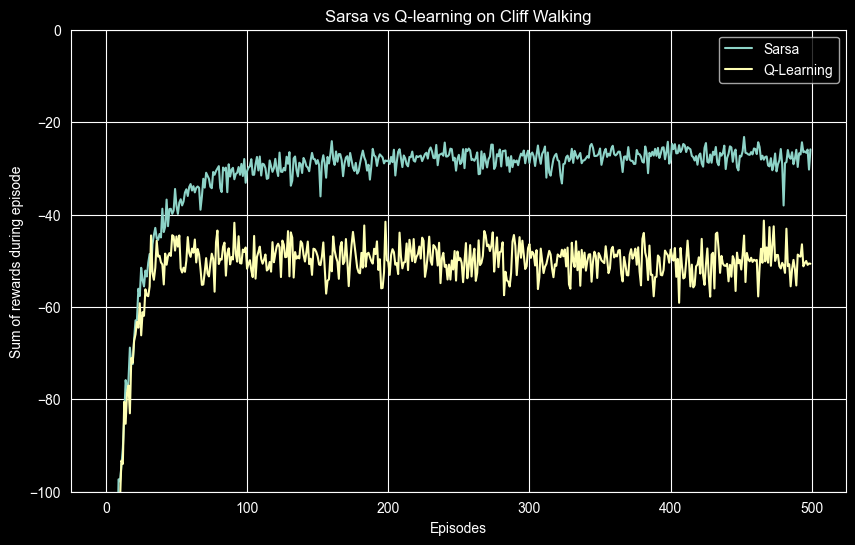

In [15]:
def run_comparison():
    episodes = 500
    runs = 500
    epsilon = 0.1
    step_size = 0.5

    rewards_sarsa = np.zeros(episodes)
    rewards_q_learning = np.zeros(episodes)

    for _ in range(runs):
        q_sarsa = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, len(ACTIONS)))
        q_q_learning = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, len(ACTIONS)))
        for i in range(episodes):
            rewards_sarsa[i] += sarsa(q_sarsa, step_size, epsilon)
            rewards_q_learning[i] += q_learning(q_q_learning, step_size, epsilon)

    rewards_sarsa /= runs
    rewards_q_learning /= runs

    plt.figure(figsize=(10, 6))
    plt.plot(rewards_sarsa, label='Sarsa')
    plt.plot(rewards_q_learning, label='Q-Learning')
    plt.xlabel('Episodes')
    plt.ylabel('Sum of rewards during episode')
    plt.ylim([-100, 0])
    plt.legend()
    plt.title('Sarsa vs Q-learning on Cliff Walking')
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    run_comparison()
